# 6  分類のためのファインチューニング

## 6.1 ファインチューニングの様々なカテゴリ

**インストラクションチューニング** (instruction fine-tuning): 特定の指示を使った一連のタスクで言語モデルを訓練
- 広範な用途に柔軟に対応
- 学習に大規模データが必要

**分類チューニング**  (classification fine-tuning): 特定のラベルを認識するように訓練  
- 限定的で専門的なタスクを対象
- 計算リソース小

## 6.2 データセットを準備する

In [1]:
import urllib.request
import zipfile
import os
from pathlib import Path

url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"
zip_path = "sms_spam_collection.zip"
extracted_path = "./src/sms_spam_collection"
data_file_path = Path(extracted_path) / "SMSSpamCollection.tsv"

def download_and_unzip_spam_data(url, zip_path, extracted_path,
                                 data_file_path):
    if data_file_path.exists():
        print(f"{data_file_path} already exists. Skipping download. "
              f"and extraction.")
        return
    
    with urllib.request.urlopen(url) as response:
        with open(zip_path, 'wb') as out_file:
            out_file.write(response.read())
            
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extracted_path)
    
    original_file_path = Path(extracted_path) / "SMSSpamCollection"
    os.rename(original_file_path, data_file_path)
    print(f"File downloaded and saved as {data_file_path}")

download_and_unzip_spam_data(url, zip_path,
                             extracted_path, data_file_path)

src/sms_spam_collection/SMSSpamCollection.tsv already exists. Skipping download. and extraction.


In [2]:
import pandas as pd
df = pd.read_csv(
    data_file_path, sep="\t", header=None, names=["Label", "Text"]
)
df

,Label,Text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [3]:
df["Label"].value_counts()

Label
ham     4825
spam     747
Name: count, dtype: int64

`ham` : スパムではない  
`spam` : スパム

均衡なデータセットを作成する

In [4]:
def create_balanced_dataset(df):
    spam_set = df[df["Label"] == "spam"]
    num_spam = spam_set.shape[0]
    ham_subset = df[df["Label"] == "ham"].sample(
        num_spam, random_state=123
        )

    balanced_df = pd.concat([
        ham_subset, spam_set
    ])
    
    return balanced_df

balanced_df = create_balanced_dataset(df)
print(balanced_df["Label"].value_counts())

Label
ham     747
spam    747
Name: count, dtype: int64


`ham` -> 0  
`spam` -> 1  
に変換

In [5]:
balanced_df["Label"] = balanced_df["Label"].map({"ham": 0, "spam" : 1})

In [6]:
def random_split(df, train_frac, validation_frac):
    df = df.sample(
        frac=1, random_state=123
    ).reset_index(drop=True) # DataFrameをシャッフル
    train_end = int(len(df) * train_frac) # 分割インデクスを計算
    validation_end = train_end + int(len(df) * validation_frac)
    
    train_df = df[:train_end] # トレーニングデータ
    validation_df = df[train_end:validation_end] # 検証データ
    test_df = df[validation_end:]
    
    return train_df, validation_df, test_df

In [7]:
train_df, validation_df, test_df = random_split(
    balanced_df, train_frac=0.7, validation_frac=0.1
)

In [8]:
train_df.to_csv("./out/train.csv", index=None)
validation_df.to_csv("./out/validation.csv", index=None)
test_df.to_csv("./out/test.csv", index=None)

## 6.3 データローダーを作成する

文字列の大きさがバラバラなので埋め込み時に `<|endoftext|>` トークンの埋め込みを付与する

In [9]:
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")
print(tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"}))

[50256]


CSV から文字列を読み取りトークン化して、シーケンスを同じ長さに揃える

In [10]:
import torch
from torch.utils.data import Dataset

class SpamDataset(Dataset):
    def __init__(self, csv_file, tokenizer, max_length=None,
                 pad_token_id=50256):
        self.data = pd.read_csv(csv_file)
        
        self.encoded_texts = [
            tokenizer.encode(text) for text in self.data["Text"]
        ]
        
        if max_length is None:
            self.max_length = self._longest_encoded_length()
        else:
            self.max_length = max_length
            
            self.encoded_texts = [
                encoded_text[:self.max_length]
                for encoded_text in self.encoded_texts
            ]
        
        self.encoded_texts = [
            encoded_text + [pad_token_id] *
            (self.max_length - len(encoded_text))
            for encoded_text in self.encoded_texts
        ]
    
    def __getitem__(self, index):
        encoded = self.encoded_texts[index]
        label = self.data.iloc[index]["Label"]
        return (
            torch.tensor(encoded, dtype=torch.long),
            torch.tensor(label, dtype=torch.long)
        )
    
    def __len__(self):
        return len(self.data)

    def _longest_encoded_length(self):
        max_length = 0
        for encoded_text in self.encoded_texts:
            encoded_length = len(encoded_text)
            if encoded_length > max_length:
                max_length = encoded_length

        return max_length

In [11]:
train_dataset = SpamDataset(
    csv_file = "./out/train.csv",
    max_length=None,
    tokenizer=tokenizer
)

In [12]:
print(train_dataset.max_length)

120


テキストメッセージの基本的な長さが 120 トークンらしい。もっと引き伸ばしたいときは `max_length=1024` にして、モデルがサポートしているコンテキスト(入力)サイズで抑えられる

In [13]:
val_dataset = SpamDataset(
    csv_file="./out/validation.csv",
    max_length = train_dataset.max_length,
    tokenizer=tokenizer
)

In [14]:
test_dataset = SpamDataset(
    csv_file="./out/test.csv",
    max_length=train_dataset.max_length,
    tokenizer=tokenizer
)

PyTorch データーローダーの作成

In [15]:
from torch.utils.data import DataLoader

num_workers = 0
batch_size = 8
torch.manual_seed(123)

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    drop_last=True
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    drop_last=False
)
test_loader=DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    drop_last=False
)

In [16]:
for input_batch, target_batch in train_loader:
    pass
print("Input batch dimension:", input_batch.shape)
print("Label batch dimensions:", target_batch.shape)

Input batch dimension: torch.Size([8, 120])
Label batch dimensions: torch.Size([8])


8 つのバッチからなる

In [17]:
print(f"{len(train_loader)} training batches")
print(f"{len(val_loader)} validation batches")
print(f"{len(test_loader)} test batches")

130 training batches
19 validation batches
38 test batches


## 6.4 事前学習済みの重みでモデルを初期化する

In [18]:
CHOOSE_MODEL = "gpt2-small (124M)"
INPUT_PROMPT = "Every effort moves"

BASE_CONFIG = {
    "vocab_size" : 50257,
    "context_length" : 1024,
    "drop_rate" : 0.0,
    "qkv_bias" : True
}

model_configs = {
    "gpt2-small (124M)" : {"emb_dim":768, "n_layers" : 12, "n_heads" : 12},
    "gpt2-medium (355M)" : {"emb_dim":1024, "n_layers" : 24, "n_heads" : 16},
    "gpt2-large (774M)" : {"emb_dim":7280, "n_layers" : 36, "n_heads" : 20},
    "gpt2-xl (1558M)" : {"emb_dim":1600, "n_layers" : 48, "n_heads" : 25}
}

BASE_CONFIG.update(model_configs[CHOOSE_MODEL])

事前学習した GPT モデルを読みこむ

In [19]:
from src.gpt_download import  download_and_load_gpt2
from previous_chapters import GPTModel, load_weights_into_gpt

model_size = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")
settings, params = download_and_load_gpt2(
    model_size=model_size, models_dir="gpt2"
)

model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)
model.eval()

2025-08-29 21:32:41.557575: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-08-29 21:32:41.565934: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1756470761.577055  124752 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1756470761.580270  124752 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1756470761.587942  124752 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

File already exists and is up-to-date: gpt2/124M/checkpoint
File already exists and is up-to-date: gpt2/124M/encoder.json
File already exists and is up-to-date: gpt2/124M/hparams.json
File already exists and is up-to-date: gpt2/124M/model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2/124M/model.ckpt.index
File already exists and is up-to-date: gpt2/124M/model.ckpt.meta
File already exists and is up-to-date: gpt2/124M/vocab.bpe


GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=7

In [20]:
from previous_chapters import generate_text_simple, text_to_token_ids, token_ids_to_text

In [21]:
text_1 = "Every effort moves you"
token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(text_1, tokenizer),
    max_new_tokens=15,
    context_size=BASE_CONFIG["context_length"]
)
print(token_ids_to_text(token_ids, tokenizer))

Every effort moves you forward.

The first step is to understand the importance of your work


In [22]:
text_2 = (
    "Is the following text 'spam'? Answer with 'yes' or 'no':"
    " 'You are winner you have been specially"
    " selected to receive &1000 cash or a $2000 award.'"
)

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(text_2, tokenizer),
    max_new_tokens=23,
    context_size=BASE_CONFIG["context_length"])
print(token_ids_to_text(token_ids, tokenizer))

Is the following text 'spam'? Answer with 'yes' or 'no': 'You are winner you have been specially selected to receive &1000 cash or a $2000 award.'

The following text 'spam'? Answer with 'yes' or 'no': 'You are winner you


まだ訓練されていないのでうまく返せない。

## 6.5 分類ヘッドを追加する

最後の層で語彙のトークンに埋め込んでいたところ `out_head` を、`spam` または `ham` の 2 値に埋め込む

モデルの凍結を行う -> 層を訓練不可能にする

In [23]:
for param in model.parameters():
    param.requires_grad = False

埋め込み次元を変更

In [24]:
num_classes = 2
model.out_head = torch.nn.Linear(
    in_features=BASE_CONFIG["emb_dim"],
    out_features=num_classes
)

`out_head` だけ訓練しておけばよいが、最後の `Transformer` ブロックと `LayerNorm` も訓練可能にしておくと、より精度が上がるらしいのでそうする。

In [25]:
# Transformer 最後のブロックを訓練可能にする
for param in model.trf_blocks[-1].parameters():
    param.requires_grad = True

# 最後の正規化層を訓練可能にする
for param in model.final_norm.parameters():
    param.requires_grad = True

In [26]:
# 新しく追加した層は勝手に訓練可能になるっぽい
print(model.out_head.parameters().__next__().requires_grad)

True


In [27]:
inputs = tokenizer.encode("Do you have time")
inputs = torch.tensor(inputs).unsqueeze(0)
print('Inputs:', inputs)
print('Inputs dimension:', inputs.shape)

Inputs: tensor([[5211,  345,  423,  640]])
Inputs dimension: torch.Size([1, 4])


In [28]:
with torch.no_grad():
    outputs = model(inputs)

print("Outputs:\n", outputs)
print("Outputs dimension:", outputs.shape)

Outputs:
 tensor([[[-1.3074,  1.6859],
         [-7.4484,  5.6707],
         [-6.9117,  5.6700],
         [-4.0557,  4.5710]]])
Outputs dimension: torch.Size([1, 4, 2])


In [29]:
print("Last output token:", outputs[:, -1, :])

Last output token: tensor([[-4.0557,  4.5710]])


Casual Attention Mask において、シーケンス内のすべてのデータにアクセスできるのは最後の成分だけなので最後が重要．

## 6.6 分類の損失と正解率を計算する

In [30]:
print("Last output token:", outputs[:, -1, :])

Last output token: tensor([[-4.0557,  4.5710]])


In [31]:
probas = torch.softmax(outputs[:, -1, :], dim=-1)
label = torch.argmax(probas)
print("Class label:", label.item())

Class label: 1


つまり、`spam` だと判定している．

最も高い値を採用するので `softmax` を使用する必要はない

In [32]:
logits = outputs[:, -1, :]
label = torch.argmax(logits)
print("Class label:", label.item())

Class label: 1


予測値割合を計算

In [33]:
def calc_accuracy_loader(data_loader, model, device, num_batches=None):
    model.eval()
    correct_predictions, num_examples = 0, 0
    
    if num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))
    
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            input_batch = input_batch.to(device)
            target_batch = target_batch.to(device)
            
            with torch.no_grad():
                logits = model(input_batch)[:, -1, :]
                
            predicted_labels = torch.argmax(logits, dim=-1)
            
            num_examples += predicted_labels.shape[0]
            correct_predictions += (
                (predicted_labels == target_batch).sum().item()
            )
        else:
            break
        return correct_predictions /num_examples

In [34]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

torch.manual_seed(123)
train_accuracy = calc_accuracy_loader(
    train_loader, model, device, num_batches=10
)
val_accuracy = calc_accuracy_loader(
    val_loader, model, device, num_batches=10
)
test_accuracy = calc_accuracy_loader(
    test_loader, model, device, num_batches=10
)
print(f"Training accuracy: {train_accuracy*100:.2f}%")
print(f"Validation accuracy: {val_accuracy*100:.2f}%")
print(f"Test accuracy: {test_accuracy*100:.2f}%")

Training accuracy: 25.00%
Validation accuracy: 50.00%
Test accuracy: 62.50%


50% に近い．これはまだ訓練していないから．

まずは損失関数を定義する．

In [35]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch = input_batch.to(device)
    target_batch = target_batch.to(device)
    logits = model(input_batch)[:, -1, :]
    loss = torch.nn.functional.cross_entropy(logits, target_batch)
    
    return loss

In [36]:
def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))
    
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(
                input_batch, target_batch, model, device
            )
            total_loss += loss.item()
        else:
            break
    return total_loss

最初の損失値を求めてみる

In [37]:
with torch.no_grad(): # まだモデルを訓練していないので勾配の追跡を無効にする
    train_loss = calc_accuracy_loader(
        train_loader, model, device, num_batches=5
    )
    val_loss = calc_loss_loader(val_loader, model, device, num_batches=5)
    test_loss = calc_loss_loader(test_loader, model, device, num_batches=5)

print(f"Training loss: {train_loss:.3f}")
print(f"validation loss: {val_loss:.3f}")
print(f"Test loss {test_loss:.3f}")

Training loss: 0.875
validation loss: 30.260
Test loss 27.169


## 6.7 教師ありデータでのモデルのファインチューニング

In [38]:
def train_classifier_simple(model, train_loader, val_loader, optimizer, 
                            device, num_epochs, eval_freq, eval_iter):
    train_losses, val_losses, train_accs, val_accs = [], [], [], [] # 損失
    examples_seen, global_step = 0, -1 # 既視のサンプル追跡
    
    for epoch in range(num_epochs): # メインの訓練ループ
        model.train() # モデルを訓練モードにする
        
        for input_batch, target_batch in train_loader:
            optimizer.zero_grad() # 前回のバッチの反復処理で計算された損失の勾配をリセット
            loss = calc_loss_batch(
                input_batch, target_batch, model, device
            )
            loss.backward() # 損失の勾配を計算
            optimizer.step() # 損失の勾配を使ってモデルの重みを更新
            examples_seen += input_batch.shape[0] # 処理済みのサンプルの追跡
            global_step += 1
            
            if global_step % eval_freq==0: # オプションの評価ステップ
                train_loss, val_loss = evaluate_model( 
                    model, train_loader, val_loader, device, eval_iter
                )
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                print(f"Ep {epoch+1} (Step {global_step:06d}) :"
                      f"Train Loss {train_loss:.3f}"
                      f"Val loss {val_loss:.3f}")
        
        train_accuracy = calc_accuracy_loader( # 各エポック終了時に正解率を計算
            train_loader, model, device, num_batches=eval_iter
        )
        val_accuracy = calc_accuracy_loader(
            val_loader, model, device, num_batches=eval_iter
        )
        print(f"Training accuracy: {train_accuracy*100:.2f}% | ", end="")
        print(f"Validation accuracy: {val_accuracy*100:.2f}%")
        train_accs.append(train_accuracy)
        val_accs.append(val_accuracy)
        
    return train_losses, val_losses, train_accs, val_accs, examples_seen

def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(
            train_loader, model, device, num_batches=eval_iter
        )
        val_loss = calc_loss_loader(
            val_loader, model, device, num_batches=eval_iter
        )
    
    model.train()
    return train_loss, val_loss


In [39]:
import time
start_time = time.time()
torch.manual_seed(123)
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.1)
num_epochs = 5

train_losses, val_losses, train_accs, val_accs, examples_seen = \
    train_classifier_simple(
        model, train_loader, val_loader, optimizer, device,
        num_epochs=num_epochs, eval_freq=50, eval_iter=5
    )

end_item = time.time()
execution_time_minutes = (end_item - start_time)//60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000) :Train Loss 26.390Val loss 29.347
Ep 1 (Step 000050) :Train Loss 3.341Val loss 3.360
Ep 1 (Step 000100) :Train Loss 2.975Val loss 3.166
Training accuracy: 37.50% | Validation accuracy: 50.00%
Ep 2 (Step 000150) :Train Loss 2.907Val loss 2.823
Ep 2 (Step 000200) :Train Loss 2.482Val loss 2.446
Ep 2 (Step 000250) :Train Loss 2.146Val loss 2.084
Training accuracy: 75.00% | Validation accuracy: 87.50%
Ep 3 (Step 000300) :Train Loss 1.581Val loss 1.717
Ep 3 (Step 000350) :Train Loss 1.295Val loss 1.004
Training accuracy: 87.50% | Validation accuracy: 100.00%
Ep 4 (Step 000400) :Train Loss 0.495Val loss 0.733
Ep 4 (Step 000450) :Train Loss 0.911Val loss 0.472
Ep 4 (Step 000500) :Train Loss 1.116Val loss 0.507
Training accuracy: 87.50% | Validation accuracy: 100.00%
Ep 5 (Step 000550) :Train Loss 0.998Val loss 0.459
Ep 5 (Step 000600) :Train Loss 0.218Val loss 0.275
Training accuracy: 100.00% | Validation accuracy: 100.00%
Training completed in 0.00 minutes.


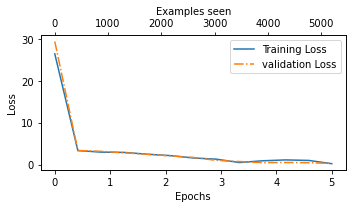

In [40]:
import matplotlib.pyplot as plt

def plot_values(epochs_seen, examples_seen, train_values, val_values,
                label="Loss"):
    fig, ax1 = plt.subplots(figsize=(5, 3))
    ax1.plot(epochs_seen, train_values, label=f"Training {label}")
    ax1.plot(
        epochs_seen, val_values, linestyle="-.",
        label=f"validation {label}"
    )
    
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel(label.capitalize())
    ax1.legend()
    
    ax2 = ax1.twiny()
    ax2.plot(examples_seen, train_values, alpha=0)
    ax2.set_xlabel("Examples seen")
    
    fig.tight_layout()
    plt.savefig(f"{label}-plot.jpg")
    plt.show()

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_losses))

plot_values(epochs_tensor, examples_seen_tensor, train_losses, val_losses)

過学習をうまく避けていることがわかる

**エポック数の目安**  
大体 5 から始めるといいらしい．過学習やまだ下がる見込みがある場合にエポック数を調整すればよい

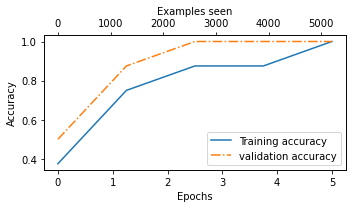

In [41]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_accs))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_accs))

plot_values(
    epochs_tensor, examples_seen_tensor, train_accs, val_accs,
    label="accuracy"
)

不思議なことに検証データの方が早く適合している．

## 6.8 スパム分類器として使ってみる

In [42]:
def classify_review(text, model, tokenizer, device, max_length=None,
                    pad_token_id=50256):
    model.eval()
    
    input_ids = tokenizer.encode(text)
    supported_context_length = model.pos_emb.weight.shape[1]
    
    input_ids = input_ids[:min(
        max_length, supported_context_length
    )]
    
    input_ids += [pad_token_id] * (max_length - len(input_ids))
    
    input_tensor = torch.tensor(
        input_ids, device=device
    ).unsqueeze(0)
    
    with torch.no_grad():
        logits = model(input_tensor)[:, -1, :]
    
    predicted_label = torch.argmax(logits, dim=-1).item()
    
    return "spam" if predicted_label == 1 else "not spam"


In [ ]:
text_1 = (
    "You are winner you have been specially"
    " selected to receive cash or a $2000 award"
)

text_2 = (
    "Hey, just wanted to check if we're still on"
    " for dinner tonight? Let me know!"
)

In [83]:
print(classify_review(
    text_1, model, tokenizer, device, max_length= train_dataset.max_length
))
print(classify_review(
    text_2, model, tokenizer, device, max_length= train_dataset.max_length
))

spam
not spam


In [87]:
my_text = ("We're glad to let you know that you won the prize!"
          " Please send us your age, adress by replyng this e-mail")

In [88]:
print(classify_review(
    my_text, model, tokenizer, device, max_length= train_dataset.max_length
))

spam


In [90]:
torch.save(model.state_dict(), "out/review_classifier.pth")

In [92]:
model_state_dict = torch.load(
    "out/review_classifier.pth", map_location=device, weights_only=True
)
model.load_state_dict(model_state_dict)

<All keys matched successfully>